# Introduction to Potentials

galpy provides a large library of gravitational potentials. This notebook covers how to
initialize potentials, evaluate them, combine them, and compute useful dynamical quantities.

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    MiyamotoNagaiPotential,
    NFWPotential,
    HernquistPotential,
    LogarithmicHaloPotential,
    MWPotential2014,
)
from galpy.util import conversion

## Initializing a potential

Let's start by creating a Miyamoto-Nagai disk potential. In galpy's natural units,
velocities are normalized to the circular velocity at the Sun, and distances to the
Sun's Galactocentric radius.

In [2]:
mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=1.0)
mp

MiyamotoNagaiPotential with internal parameters: amp=1.4632953564490085, a=0.5, b=0.0375 and physical outputs off

## Evaluating potential values and forces

Evaluate the potential at (R, z) = (1, 0), i.e., the solar position in natural units:

In [3]:
# Potential value at (R, z) = (1, 0)
print("Phi(R=1, z=0) =", mp(1.0, 0.0))

Phi(R=1, z=0) = -1.2889062500000001


In [4]:
# Radial and vertical forces
print("F_R(R=1, z=0) =", mp.Rforce(1.0, 0.0))
print("F_z(R=1, z=0.1) =", mp.zforce(1.0, 0.1))

F_R(R=1, z=0) = -1.0
F_z(R=1, z=0.1) = -0.5194918992748312


## The functional interface

galpy also provides module-level functions that work on single potentials or lists of potentials:

In [5]:
print("evaluatePotentials:", potential.evaluatePotentials(mp, 1.0, 0.0))
print("evaluateRforces:", potential.evaluateRforces(mp, 1.0, 0.0))
print("evaluatezforces:", potential.evaluatezforces(mp, 1.0, 0.1))

evaluatePotentials: -1.2889062500000001
evaluateRforces: -1.0
evaluatezforces: -0.5194918992748312


## Combining potentials

Potentials can be combined using the `+` operator. `MWPotential2014` is a built-in
composite potential with three components:

In [6]:
# MWPotential2014 is a composite potential
print(type(MWPotential2014))
print("Number of components:", len(MWPotential2014))
for p in MWPotential2014:
    print(" ", type(p).__name__)

<class 'galpy.potential.CompositePotential.CompositePotential'>
Number of components: 3
  PowerSphericalPotentialwCutoff
  MiyamotoNagaiPotential
  NFWPotential


In [7]:
# You can also combine potentials yourself
my_pot = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.6) + NFWPotential(
    a=4.5, normalize=0.35
)
print("Phi(1,0) =", potential.evaluatePotentials(my_pot, 1.0, 0.0))

Phi(1,0) = -4.498828040219292


## Converting to physical units

To convert from natural units to physical units, use `galpy.util.conversion`:

In [8]:
ro, vo = 8.0, 220.0  # kpc, km/s
# Force in natural units
F_R_nat = potential.evaluateRforces(MWPotential2014, 1.0, 0.0)
# Convert to physical (km/s^2/kpc)
F_R_phys = F_R_nat * conversion.force_in_kmsMyr(vo, ro) / 1000.0  # to km/s^2/kpc
print(
    f"F_R at solar position: {F_R_nat:.4f} (natural), {F_R_phys:.6f} km/s^2/kpc (physical)"
)

F_R at solar position: -1.0000 (natural), -0.006187 km/s^2/kpc (physical)


## Densities

You can evaluate the density directly or via the Poisson equation:

In [9]:
# Direct density evaluation
print("Density (direct):", mp.dens(1.0, 0.0))
# Via the Poisson equation
print("Density (Poisson):", mp.dens(1.0, 0.0, forcepoisson=True))

Density (direct): 1.1145444383277576
Density (Poisson): 1.1145444383277574


In [10]:
# Functional interface for lists of potentials
print(
    "MWPotential2014 density at (1,0):",
    potential.evaluateDensities(MWPotential2014, 1.0, 0.0),
)

MWPotential2014 density at (1,0): 0.5750860312226487


## Plotting potentials

galpy potentials have built-in plotting methods:

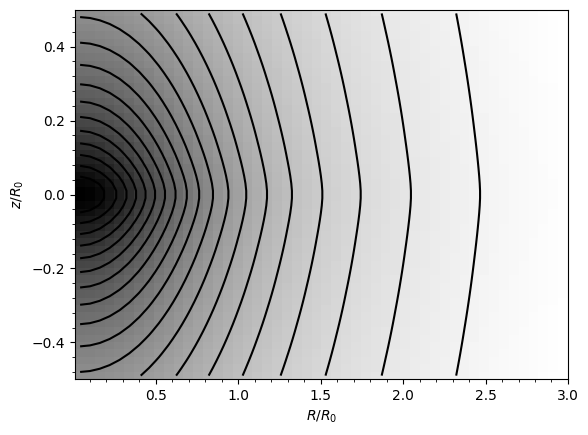

In [11]:
# Plot the potential in the (R, z) plane
mp.plot(rmin=0.01, rmax=3.0, zmin=-0.5, zmax=0.5, nrs=50, nzs=50)

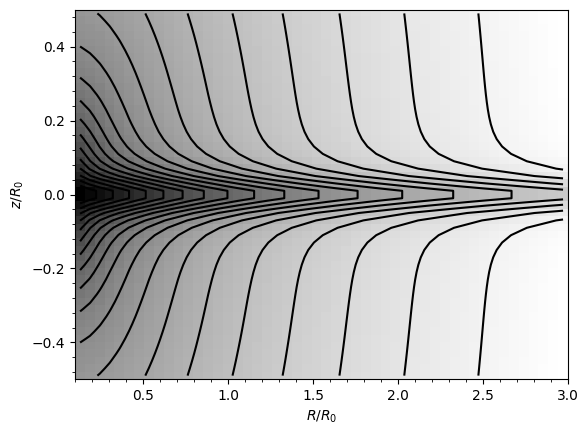

In [12]:
# Plot the density
potential.plotDensities(
    MWPotential2014, rmin=0.1, rmax=3.0, zmin=-0.5, zmax=0.5, nrs=50, nzs=50, log=True
)

## Circular-orbit quantities

galpy can compute circular velocity, epicycle frequency, vertical frequency,
and angular frequency:

In [13]:
print("v_circ(R=1):", MWPotential2014.vcirc(1.0))
print("Omega_c(R=1):", MWPotential2014.omegac(1.0))
print("Epicycle freq(R=1):", MWPotential2014.epifreq(1.0))
print("Vertical freq(R=1):", MWPotential2014.verticalfreq(1.0))

v_circ(R=1): 1.0
Omega_c(R=1): 1.0
Epicycle freq(R=1): 1.340959647011537
Vertical freq(R=1): 2.7255405754769875


(0.0, 1.5)

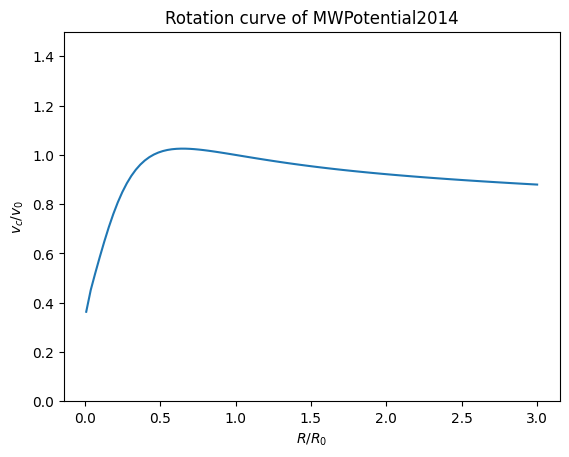

In [14]:
# Plot the rotation curve
Rs = numpy.linspace(0.01, 3.0, 101)
plt.plot(Rs, [MWPotential2014.vcirc(R) for R in Rs])
plt.xlabel(r"$R / R_0$")
plt.ylabel(r"$v_c / v_0$")
plt.title("Rotation curve of MWPotential2014")
plt.ylim(0, 1.5)

## Lindblad resonances

Find the radius of the inner and outer Lindblad resonances for a given pattern speed:

In [15]:
# Pattern speed for a bar (e.g., 1.8 Omega_0)
OmegaP = 1.8
# Inner Lindblad resonance
ilr = MWPotential2014.lindbladR(OmegaP, m=2)
print(f"Inner Lindblad resonance: R = {ilr:.4f} R_0")
# Outer Lindblad resonance
olr = MWPotential2014.lindbladR(OmegaP, m=-2)
print(f"Outer Lindblad resonance: R = {olr:.4f} R_0")

Inner Lindblad resonance: R = 0.0561 R_0
Outer Lindblad resonance: R = 0.9359 R_0


## Interpolated potentials

For expensive potentials, galpy provides `interpRZPotential` (for axisymmetric potentials)
and `interpSphericalPotential` (for spherical potentials) that pre-compute a grid and
interpolate:

In [16]:
from galpy.potential import interpRZPotential

# Create an interpolated version of MWPotential2014
ip = interpRZPotential(
    RZPot=MWPotential2014,
    rgrid=(0.01, 3.0, 51),
    zgrid=(0.0, 0.5, 26),
    interpPot=True,
    interpRforce=True,
    interpzforce=True,
)
# Compare
print("Original:", potential.evaluatePotentials(MWPotential2014, 1.0, 0.1))
print("Interpolated:", ip(1.0, 0.1))

Original: -1.3531320418152721
Interpolated: -1.3531320418152721


## Initializing with physical units

You can initialize potentials using physical units by setting `ro` and `vo` and
passing physical parameters:

In [17]:
from astropy import units as u

# NFW halo with a mass and scale radius in physical units
nfw = NFWPotential(mvir=1.0, conc=15.0, ro=8.0, vo=220.0)
# Evaluate at 8 kpc -- returns in physical units (km^2/s^2) when using quantities
print("Phi(8 kpc, 0 kpc):", nfw(8.0 * u.kpc, 0.0 * u.kpc))

Phi(8 kpc, 0 kpc): -96354.67477240822


In [18]:
# Miyamoto-Nagai with physical amplitude
mn_phys = MiyamotoNagaiPotential(
    amp=5e10 * u.Msun, a=3.0 * u.kpc, b=0.28 * u.kpc, ro=8.0, vo=220.0
)
print("v_circ(R=1):", mn_phys.vcirc(1.0))

v_circ(R=1): 145.9185599862874
